<a href="https://colab.research.google.com/github/Nishkarsh2917/ml/blob/main/Copy_of_IMDb_Sentiment_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets -q

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete!")

Setup complete!


### Step 1: Load and Subset the Data
We will use `load_dataset("stanfordnlp/imdb")`. To save time and memory, we will only use the first 5,000 rows for training and 1,000 for testing.

In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("stanfordnlp/imdb")

# Extract the text (features) and labels from the train and test splits.
# Subset them: take the first 5000 from train, and first 1000 from test.
train_subset = dataset['train'].shuffle(seed=42).select(range(5000))

X_train = train_subset['text']
y_train = train_subset['label']

# TODO: Extract the test subset, shuffle, and select 1000 rows
test_subset = dataset['test'].shuffle(seed=42).select(range(1000))

X_test = test_subset['text']
y_test = test_subset['label']

print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loaded 5000 training reviews and 1000 testing reviews.


### Step 2: Word to Math (TF-IDF)
Machines can't read English. We need to convert these text reviews into numbers using a `TfidfVectorizer`.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: Initialize the TfidfVectorizer. (Optional: limit max_features to 5000 to keep it fast)
vectorizer = TfidfVectorizer(max_features=5000)

# TODO: fit_transform the training data, and just transform the testing data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Data vectorized!")

Data vectorized!


### Step 3: Train the Model
Time to train the Classical ML algorithm: Logistic Regression.

In [ ]:
from sklearn.linear_model import LogisticRegression

# TODO: Initialize LogisticRegression and fit it to your vectorized training data
model = LogisticRegression()
model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


### Step 4: Evaluate
How good is your AI movie critic? Let's predict on the test set and calculate the metrics.

Accuracy: 0.8460
F1 Score: 0.8454

Confusion Matrix:
[[425  87]
 [ 67 421]]


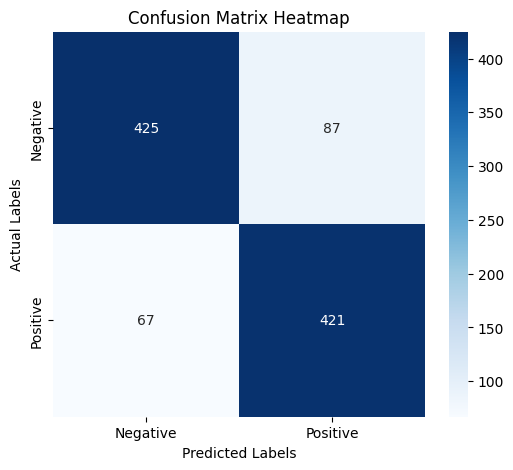

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# TODO: Predict on X_test_vec
y_pred = model.predict(X_test_vec)

# TODO: Calculate and print the Accuracy and F1 Score
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# TODO: Generate the confusion matrix and print it
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Bonus: Plotting using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()